<a href="https://colab.research.google.com/github/eshan14git/football-qa-nlp/blob/eshan-dev/notebooks/06_LSTM_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone -b eshan-dev https://github.com/eshan14git/football-qa-nlp.git

Cloning into 'football-qa-nlp'...
remote: Enumerating objects: 259, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 259 (delta 81), reused 51 (delta 22), pack-reused 112 (from 4)
Receiving objects: 100% (259/259), 38.91 MiB | 255.00 KiB/s, done.
Resolving deltas: 100% (113/113), done.


In [2]:
%cd /content/football-qa-nlp

import os

print("Current working directory:")
print(os.getcwd())

print("\nRepository contents:")
print(os.listdir("."))

/content/football-qa-nlp
Current working directory:
/content/football-qa-nlp

Repository contents:
['data', 'requirements.txt', '06_football_qa_inference.ipynb', '.git', 'README.md', 'notebooks', 'docs', '.gitignore', 'src', 'models']


In [3]:
# Core libraries
import os
import random
import pickle
import numpy as np
import pandas as pd

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check versions and GPU
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("\nGPU available:", gpus)
else:
    print("\nNo GPU detected - currently using CPU.")

TensorFlow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Check files inside the data directory
for root, dirs, files in os.walk("data"):
    level = root.replace("data", "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

data/
    goalscorers.csv
    .gitkeep
    results.csv
    shootouts_clean.csv
    former_names.csv
    shootouts.csv
    results_clean.csv
    former_names_clean.csv
    goalscorers_clean.csv


In [5]:
# Search the entire repository for the supervised intent datasets
target_files = {
    "train_dataset.csv",
    "validation_dataset.csv",
    "test_dataset.csv",
    "question_intent_dataset.csv"
}

found_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        if file in target_files:
            path = os.path.join(root, file)
            found_files.append(path)
            print(path)

if not found_files:
    print("No supervised intent dataset files were found.")

./models/features/question_intent_dataset.csv
./models/features/validation_dataset.csv
./models/features/train_dataset.csv
./models/features/test_dataset.csv


In [6]:
# Paths to the supervised intent datasets
features_path = "models/features"

train_path = os.path.join(features_path, "train_dataset.csv")
val_path = os.path.join(features_path, "validation_dataset.csv")
test_path = os.path.join(features_path, "test_dataset.csv")

# Load datasets
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Basic inspection
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nTraining dataset sample:")
display(train_df.head())

Train shape: (60729, 4)
Validation shape: (7591, 4)
Test shape: (7592, 4)

Columns:
['question', 'intent', 'answer', 'source_dataset']

Training dataset sample:


,question,intent,answer,source_dataset
0,At what minute did Arthur Avom find the net ag...,goal_minute,28,goalscorers
1,At what minute did Khairul Amri find the net a...,goal_minute,9,goalscorers
2,What was the date of France versus Azerbaijan?,match_date,2025-10-10,results
3,How many goals were scored in total when El Sa...,total_goals,4,results
4,Did Dové Womé score a penalty in the match aga...,penalty_status,No,goalscorers


In [7]:
# Check missing values
print("Missing values in training set:")
print(train_df.isnull().sum())

print("\nMissing values in validation set:")
print(val_df.isnull().sum())

print("\nMissing values in test set:")
print(test_df.isnull().sum())

# Check number of unique intents
print("\nUnique intents in training set:", train_df["intent"].nunique())

# Class distribution
intent_counts = train_df["intent"].value_counts().sort_index()

print("\nTraining intent distribution:")
print(intent_counts)

print("\nTotal training samples:", intent_counts.sum())

Missing values in training set:
question          0
intent            0
answer            0
source_dataset    0
dtype: int64

Missing values in validation set:
question          0
intent            0
answer            0
source_dataset    0
dtype: int64

Missing values in test set:
question          0
intent            0
answer            0
source_dataset    0
dtype: int64

Unique intents in training set: 15

Training intent distribution:
intent
away_team_score    4000
first_shooter      4365
goal_minute        4000
home_team_score    4000
match_date         4000
match_location     4000
match_score        4000
match_winner       4000
neutral_status     4000
own_goal_status    4000
penalty_status     4000
scorer             4000
shootout_winner    4364
total_goals        4000
tournament         4000
Name: count, dtype: int64

Total training samples: 60729


In [8]:
# Get intent sets from each split
train_intents = set(train_df["intent"].unique())
val_intents = set(val_df["intent"].unique())
test_intents = set(test_df["intent"].unique())

print("Train intents:", len(train_intents))
print("Validation intents:", len(val_intents))
print("Test intents:", len(test_intents))

print("\nTrain = Validation:", train_intents == val_intents)
print("Train = Test:", train_intents == test_intents)

print("\nIntents:")
for intent in sorted(train_intents):
    print(intent)

Train intents: 15
Validation intents: 15
Test intents: 15

Train = Validation: True
Train = Test: True

Intents:
away_team_score
first_shooter
goal_minute
home_team_score
match_date
match_location
match_score
match_winner
neutral_status
own_goal_status
penalty_status
scorer
shootout_winner
total_goals
tournament


In [9]:
# Load the previously saved LSTM tokenizer
old_tokenizer_path = "models/features/lstm_tokenizer.pkl"

with open(old_tokenizer_path, "rb") as file:
    old_tokenizer = pickle.load(file)

print("Tokenizer vocabulary size:", len(old_tokenizer.word_index))
print("Configured num_words:", old_tokenizer.num_words)
print("OOV token:", old_tokenizer.oov_token)

print("\nFirst 20 words in tokenizer:")
for word, index in list(old_tokenizer.word_index.items())[:20]:
    print(f"{word}: {index}")

Tokenizer vocabulary size: 19794
Configured num_words: 10000
OOV token: <OOV>

First 20 words in tokenizer:
<OOV>: 1
the: 2
in: 3
on: 4
against: 5
goal: 6
false: 7
and: 8
was: 9
played: 10
final: 11
score: 12
penalty: 13
scored: 14
for: 15
minute: 16
own: 17
1: 18
0: 19
06: 20


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"

# Create tokenizer
lstm_tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

# Fit ONLY on training questions
lstm_tokenizer.fit_on_texts(train_df["question"].astype(str))

print("Full tokenizer vocabulary size:", len(lstm_tokenizer.word_index))
print("Vocabulary limit used:", VOCAB_SIZE)
print("OOV token index:", lstm_tokenizer.word_index.get(OOV_TOKEN))

print("\nFirst 20 word mappings:")
for word, index in list(lstm_tokenizer.word_index.items())[:20]:
    print(f"{word}: {index}")

Full tokenizer vocabulary size: 8547
Vocabulary limit used: 10000
OOV token index: 1

First 20 word mappings:
<OOV>: 1
the: 2
and: 3
was: 4
between: 5
did: 6
against: 7
in: 8
what: 9
match: 10
score: 11
goal: 12
which: 13
who: 14
for: 15
penalty: 16
when: 17
team: 18
played: 19
on: 20


In [11]:
# Convert training questions to integer sequences
train_sequences = lstm_tokenizer.texts_to_sequences(
    train_df["question"].astype(str)
)

# Calculate sequence lengths
sequence_lengths = [len(seq) for seq in train_sequences]

print("Shortest sequence:", np.min(sequence_lengths))
print("Longest sequence:", np.max(sequence_lengths))
print("Average sequence length:", np.mean(sequence_lengths))
print("Median sequence length:", np.median(sequence_lengths))
print("95th percentile:", np.percentile(sequence_lengths, 95))
print("99th percentile:", np.percentile(sequence_lengths, 99))

Shortest sequence: 5
Longest sequence: 25
Average sequence length: 10.569085609840439
Median sequence length: 11.0
95th percentile: 14.0
99th percentile: 17.0


In [12]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_SEQUENCE_LENGTH = 20

# Convert questions into integer sequences
train_sequences = lstm_tokenizer.texts_to_sequences(
    train_df["question"].astype(str)
)

val_sequences = lstm_tokenizer.texts_to_sequences(
    val_df["question"].astype(str)
)

test_sequences = lstm_tokenizer.texts_to_sequences(
    test_df["question"].astype(str)
)

# Pad sequences to the same length
X_train = pad_sequences(
    train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    val_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\nFirst training question:")
print(train_df["question"].iloc[0])

print("\nFirst padded sequence:")
print(X_train[0])

X_train shape: (60729, 20)
X_val shape: (7591, 20)
X_test shape: (7592, 20)

First training question:
At what minute did Arthur Avom find the net against Eswatini?

First padded sequence:
[  45    9   40    6  849 6082  223    2   60    7  299    0    0    0
    0    0    0    0    0    0]


In [13]:
from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# Fit only on training intents
y_train = label_encoder.fit_transform(train_df["intent"])

# Transform validation and test using the same mapping
y_val = label_encoder.transform(val_df["intent"])
y_test = label_encoder.transform(test_df["intent"])

print("Number of classes:", len(label_encoder.classes_))

print("\nIntent label mapping:")
for index, intent in enumerate(label_encoder.classes_):
    print(f"{index}: {intent}")

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 10 encoded training labels:")
print(y_train[:10])

Number of classes: 15

Intent label mapping:
0: away_team_score
1: first_shooter
2: goal_minute
3: home_team_score
4: match_date
5: match_location
6: match_score
7: match_winner
8: neutral_status
9: own_goal_status
10: penalty_status
11: scorer
12: shootout_winner
13: total_goals
14: tournament

y_train shape: (60729,)
y_val shape: (7591,)
y_test shape: (7592,)

First 10 encoded training labels:
[ 2  2  4 13 10  7  1 14  6  5]


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

NUM_CLASSES = len(label_encoder.classes_)

INPUT_DIM = min(
    VOCAB_SIZE,
    len(lstm_tokenizer.word_index) + 1
)

EMBEDDING_DIM = 128
LSTM_UNITS = 64

model = Sequential([
    Embedding(
        input_dim=INPUT_DIM,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(
        LSTM_UNITS,
        dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 20, 128)        │     1,094,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,148,687 (4.38 MB)

 Trainable params: 1,148,687 (4.38 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Training callbacks created successfully.")

Training callbacks created successfully.


In [18]:
EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/20
949/949 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9077 - loss: 0.2856 - val_accuracy: 0.9993 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 2/20
949/949 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9965 - loss: 0.0192 - val_accuracy: 1.0000 - val_loss: 2.2405e-04 - learning_rate: 0.0010
Epoch 3/20
949/949 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9999 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 2.2252e-05 - learning_rate: 0.0010
Epoch 4/20
949/949 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9986 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 1.6682e-05 - learning_rate: 0.0010
Epoch 5/20
949/949 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9999 - loss: 0.0011
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
949/949 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 1.0000 - loss: 6.6799e-04 - val_accuracy: 1.0000 - val_loss: 4.0495e-06 - learning_rate: 0.0010
Epoch 6/20
949/949 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.99

In [19]:
# Evaluate model on the held-out test set
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Loss    : {test_loss:.6f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.2470e-07

Test Loss    : 0.000000
Test Accuracy: 1.0000


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predict probabilities for test samples
y_pred_probs = model.predict(X_test, verbose=0)

# Convert probabilities to predicted class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test, y_pred, average="weighted", zero_division=0
)
recall = recall_score(
    y_test, y_pred, average="weighted", zero_division=0
)
f1 = f1_score(
    y_test, y_pred, average="weighted", zero_division=0
)

print("LSTM Test Evaluation")
print("--------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

LSTM Test Evaluation
--------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Classification Report:

                 precision    recall  f1-score   support

away_team_score     1.0000    1.0000    1.0000       500
  first_shooter     1.0000    1.0000    1.0000       546
    goal_minute     1.0000    1.0000    1.0000       500
home_team_score     1.0000    1.0000    1.0000       500
     match_date     1.0000    1.0000    1.0000       500
 match_location     1.0000    1.0000    1.0000       500
    match_score     1.0000    1.0000    1.0000       500
   match_winner     1.0000    1.0000    1.0000       500
 neutral_status     1.0000    1.0000    1.0000       500
own_goal_status     1.0000    1.0000    1.0000       500
 penalty_status     1.0000    1.0000    1.0000       500
         scorer     1.0000    1.0000    1.0000       500
shootout_winner     1.0000    1.0000    1.0000       546
    total_goals     1.0000    1.0000    1.0000       500
     

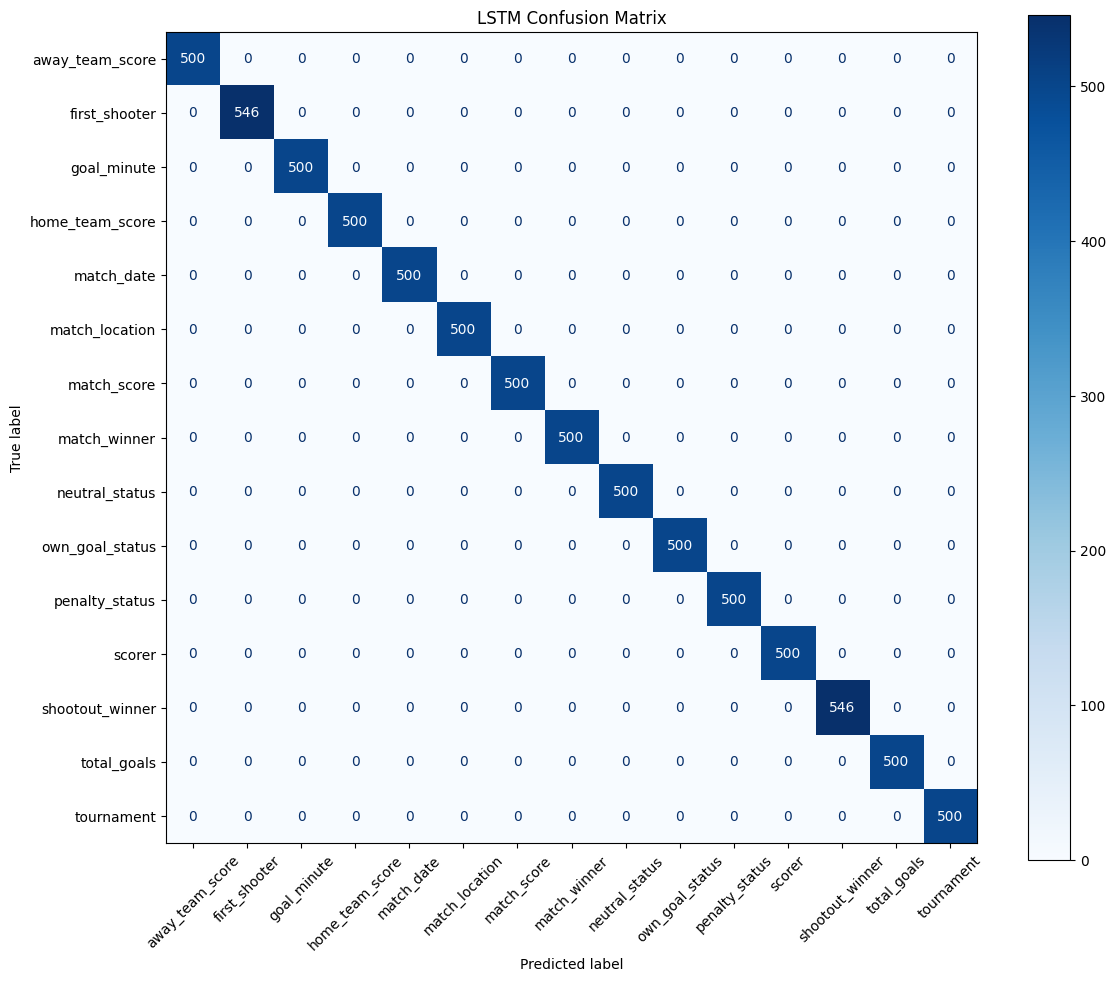

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

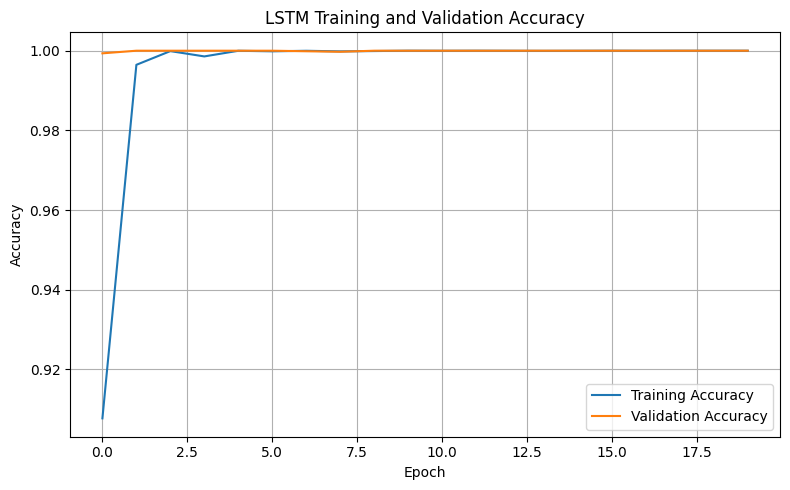

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

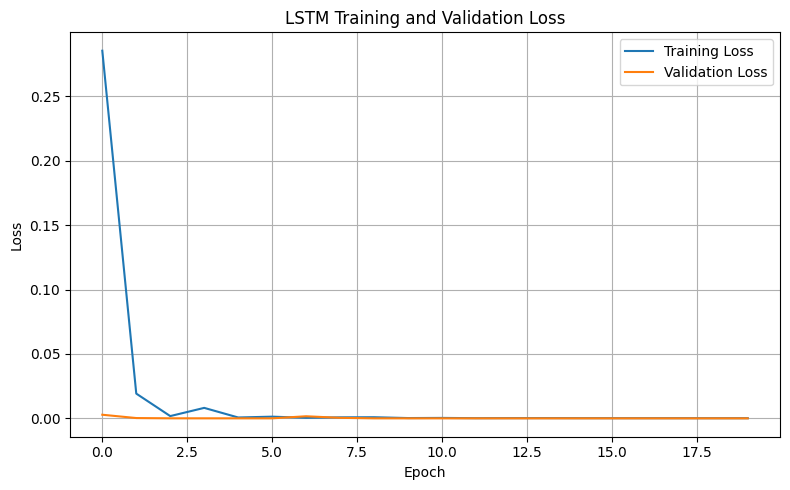

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# Create LSTM model directory
lstm_model_path = "models/lstm"
os.makedirs(lstm_model_path, exist_ok=True)

# 1. Save trained LSTM model
model.save(
    os.path.join(lstm_model_path, "lstm_intent_model.keras")
)

# 2. Save intent-specific tokenizer
with open(
    os.path.join(lstm_model_path, "lstm_tokenizer.pkl"), "wb"
) as file:
    pickle.dump(lstm_tokenizer, file)

# 3. Save label encoder
with open(
    os.path.join(lstm_model_path, "lstm_label_encoder.pkl"), "wb"
) as file:
    pickle.dump(label_encoder, file)

# 4. Save maximum sequence length
with open(
    os.path.join(lstm_model_path, "lstm_max_sequence_length.pkl"), "wb"
) as file:
    pickle.dump(MAX_SEQUENCE_LENGTH, file)

print("LSTM artifacts saved successfully.\n")

for filename in sorted(os.listdir(lstm_model_path)):
    filepath = os.path.join(lstm_model_path, filename)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)

    print(f"{filename} - {size_mb:.2f} MB")

LSTM artifacts saved successfully.

lstm_intent_model.keras - 13.18 MB
lstm_label_encoder.pkl - 0.00 MB
lstm_max_sequence_length.pkl - 0.00 MB
lstm_tokenizer.pkl - 0.33 MB


In [25]:
# Verify that all saved LSTM artifacts can be loaded

# Load model
loaded_model = tf.keras.models.load_model(
    "models/lstm/lstm_intent_model.keras"
)

# Load tokenizer
with open("models/lstm/lstm_tokenizer.pkl", "rb") as file:
    loaded_tokenizer = pickle.load(file)

# Load label encoder
with open("models/lstm/lstm_label_encoder.pkl", "rb") as file:
    loaded_label_encoder = pickle.load(file)

# Load max sequence length
with open("models/lstm/lstm_max_sequence_length.pkl", "rb") as file:
    loaded_max_length = pickle.load(file)

print("All LSTM artifacts loaded successfully.")
print("Number of classes:", len(loaded_label_encoder.classes_))
print("Max sequence length:", loaded_max_length)
print("Tokenizer vocabulary:", len(loaded_tokenizer.word_index))

All LSTM artifacts loaded successfully.
Number of classes: 15
Max sequence length: 20
Tokenizer vocabulary: 8547


In [26]:
!git status

On branch eshan-dev
Your branch is up to date with 'origin/eshan-dev'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/lstm/

nothing added to commit but untracked files present (use "git add" to track)


In [27]:
from google.colab import files

files.download("models/lstm/lstm_intent_model.keras")
files.download("models/lstm/lstm_tokenizer.pkl")
files.download("models/lstm/lstm_label_encoder.pkl")
files.download("models/lstm/lstm_max_sequence_length.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>